## Project Description

This project uses the **Adult (Census Income)** dataset from the UCI Machine Learning Repository. The dataset contains demographic, educational, occupational, and economic information extracted from the 1994 U.S. Census database. Its main objective is to determine whether an individual's annual income exceeds **$50,000 per year** based on personal and socioeconomic characteristics. The dataset includes both categorical and numerical variables, making it suitable for exploratory data analysis, unsupervised learning, and machine learning applications. [1](https://archive.ics.uci.edu/ml/datasets/Adult)[2](https://archive.ics.uci.edu/dataset/20/census+income)

## Objectives

### Data Analysis

- Explore the demographic and socioeconomic characteristics of individuals in the dataset.
- Identify patterns, distributions, and relationships among variables such as age, education, occupation, and working hours.
- Analyze how different factors influence income levels.
- Detect data quality issues, missing values, and potential outliers.

### Unsupervised Learning

- Apply clustering techniques to identify groups of individuals with similar socioeconomic profiles.
- Discover hidden patterns and segments within the population.
- Compare clusters based on income level, education, occupation, and demographic attributes.
- Use dimensionality reduction techniques to visualize complex relationships in the data.

### Machine Learning Fundamentals

- Prepare and transform categorical and numerical features for modeling.
- Select the most relevant variables influencing income classification.
- Build classification models to predict whether annual income exceeds $50K.
- Evaluate model performance using metrics such as accuracy, precision, recall, and F1-score.
- Compare different machine learning algorithms and interpret their results.

## Target Variable

- **Income**
  - `<=50K`
  - `>50K`

## Skills Demonstrated

- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Data Visualization
- Feature Engineering
- Categorical Data Encoding
- Correlation and Feature Importance Analysis
- Clustering (K-Means, Hierarchical Clustering)
- Dimensionality Reduction (PCA)
- Classification Modeling
- Machine Learning Fundamentals
- Model Evaluation and Interpretation
- Data-Driven Insights and Decision Making

## Descripción de las variables del dataset

Funente de los datos: https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

| Variable | Descripción | Tipo |
|---|---|---|
| `age` | Edad de la persona | Numérica |
| `workclass` | Tipo de empleo (privado, gobierno, etc.) | Categórica |
| `fnlwgt` | Peso asignado por el censo que representa la población | Numérica |
| `education` | Nivel educativo alcanzado | Categórica |
| `education-num` | Nivel educativo representado numéricamente | Numérica |
| `marital-status` | Estado civil de la persona | Categórica |
| `occupation` | Ocupación o tipo de trabajo | Categórica |
| `relationship` | Relación dentro del hogar (esposo, hijo, etc.) | Categórica |
| `race` | Raza de la persona | Categórica |
| `sex` | Sexo de la persona | Categórica |
| `capital-gain` | Ganancias de capital | Numérica |
| `capital-loss` | Pérdidas de capital | Numérica |
| `hours-per-week` | Número de horas trabajadas por semana | Numérica |
| `native-country` | País de origen | Categórica |
| `income` | Nivel de ingreso (>50K o <=50K) | Categórica (no usada en clustering) |


In [ ]:
#Importación de librerías principales
import pandas as pd
import numpy as np

#Visualización
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesamiento
from sklearn.preprocessing import StandardScaler

#Modelos de clustering
from sklearn.cluster import KMeans, DBSCAN

#Evaluación
from sklearn.metrics import silhouette_score


#Carga del dataset desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Definición de nombres de columnas
columns = [
    "age","workclass","fnlwgt","education","education-num",
    "marital-status","occupation","relationship","race","sex",
    "capital-gain","capital-loss","hours-per-week","native-country","income"
]

# Lectura del archivo
df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Visualización inicial
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Loading Libraries and Dataset

In this stage, the required libraries for data analysis and modeling are imported. Tools such as **pandas** and **numpy** are used for data manipulation, **matplotlib** and **seaborn** for data visualization, and **scikit-learn** modules for data preprocessing, clustering model training, and evaluation.

Next, the **Adult Income** dataset is loaded from the UCI repository. Column names are manually assigned since the original file does not contain headers. In addition, missing values represented by **"?"** are defined as null values, and unnecessary whitespace is removed.

Finally, an initial inspection of the data is performed by displaying the first few rows of the dataset. This helps understand its structure and verify that the data has been loaded correctly.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Ver dimensiones iniciales
print("Dimensiones iniciales:", df.shape)

# Ver cantidad de valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Eliminación de registros con valores faltantes
df_clean = df.dropna()

# Ver dimensiones después de la limpieza
print("\nDimensiones después de eliminar nulos:", df_clean.shape)

# Eliminación de la variable 'income' (no se usa en clustering)
df_clean = df_clean.drop(columns=["income"])

# Verificación final
df_clean.head()

Dimensiones iniciales: (32561, 15)

Valores nulos por columna:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Dimensiones después de eliminar nulos: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


## Description

Missing values in the dataset were originally represented by `"?"`, which were converted into **null values (NaN)** during the data loading process. Subsequently, records containing missing values were removed, as clustering algorithms require complete data for accurate distance calculations. Finally, the `income` variable was excluded from the analysis since it is not needed in an **unsupervised learning** approach.


#EDA – Análisis exploratorio

Variables categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Variables numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


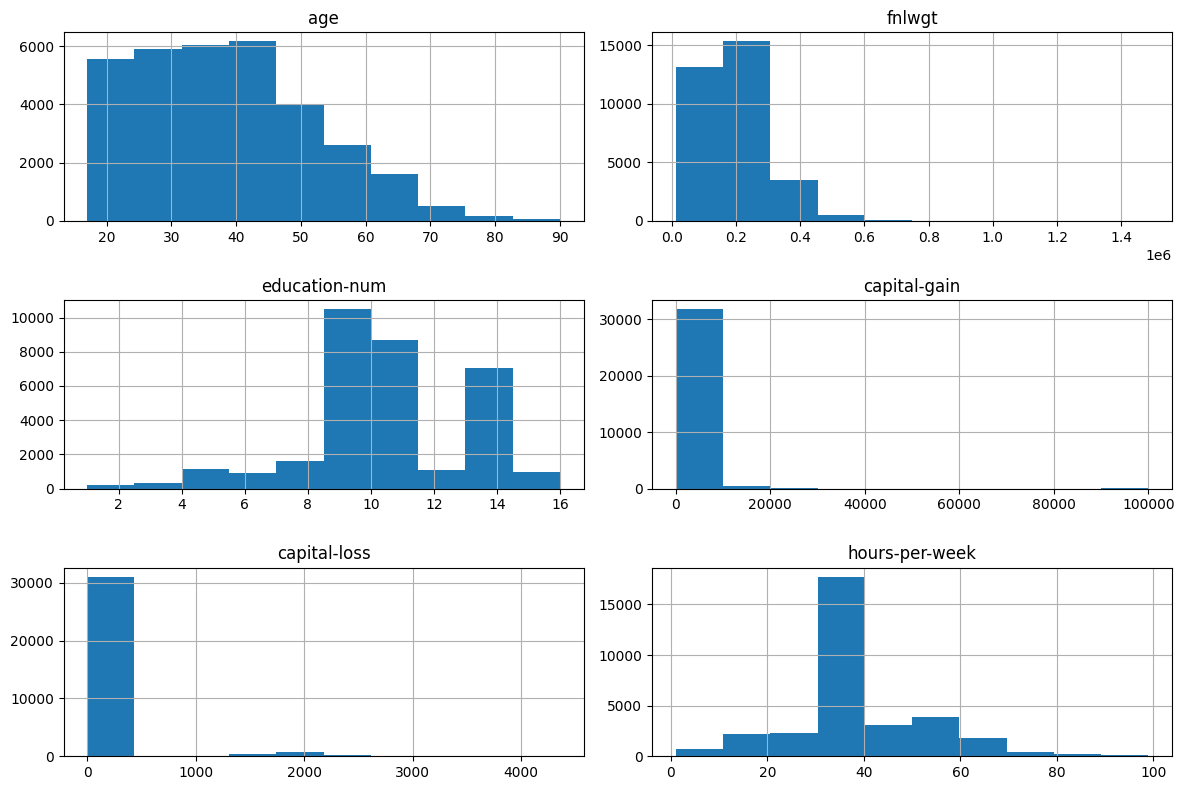

In [ ]:
# Copia del dataset limpio
df_model = df_clean.copy()

# Identificar variables categóricas y numéricas
categorical_cols = df_model.select_dtypes(include=['object']).columns
numerical_cols = df_model.select_dtypes(include=['int64', 'float64']).columns

print("Variables categóricas:", list(categorical_cols))
print("Variables numéricas:", list(numerical_cols))

# Histogramas
df_model[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


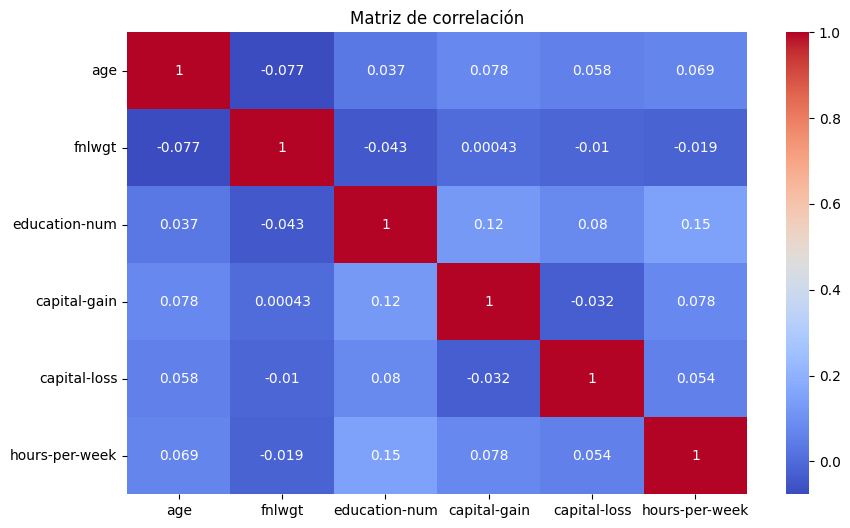

In [ ]:

#Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_model[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


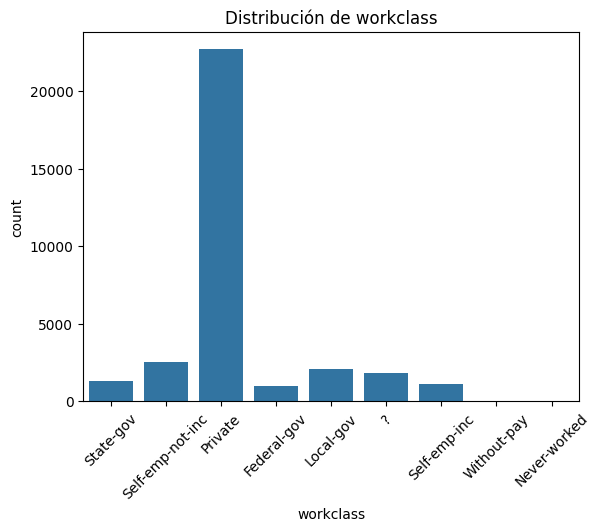

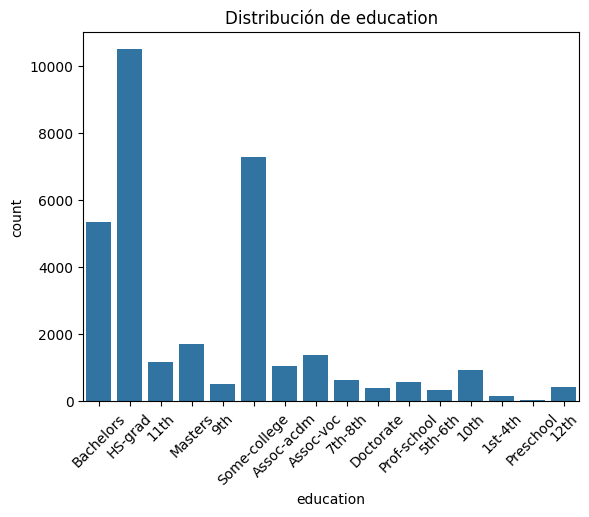

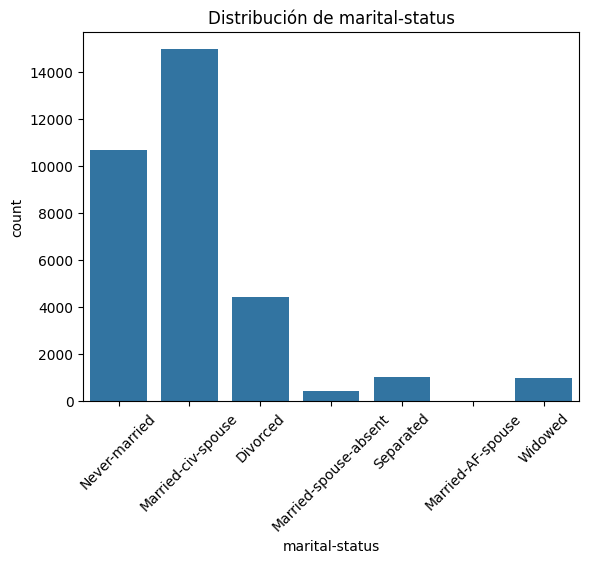

In [ ]:

 #Conteo de categorías (ejemplo)
for col in categorical_cols[:3]:  # solo algunas para no saturar
    sns.countplot(data=df_model, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    plt.show()


#Transformación (Encoding)

In [ ]:

#Convertir variables categóricas a numéricas
df_encoded = pd.get_dummies(df_model, drop_first=True)

print("Dimensiones después del encoding:", df_encoded.shape)


Dimensiones después del encoding: (32561, 100)


In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)


## Data Transformation and Exploratory Data Analysis (EDA)

In this phase, an **Exploratory Data Analysis (EDA)** was conducted to better understand the distribution, relationships, and key characteristics of the dataset.

Initially, variables were separated into **categorical** and **numerical** features, allowing the application of data-type-specific analysis techniques. For numerical variables, distributions were examined through histograms to identify potential skewness and outliers.

A **correlation matrix** was also created to evaluate relationships among numerical variables, helping to detect dependencies or redundancies within the data.

For categorical variables, category frequencies were analyzed to understand the composition of the dataset and identify potential imbalances.

Next, categorical features were transformed using **One-Hot Encoding**, converting them into binary numerical variables. This step is essential because clustering algorithms cannot directly process categorical data.

Finally, the dataset was standardized using **StandardScaler** to bring all features to the same scale. This is particularly important for distance-based algorithms such as **K-Means**, where variables with larger magnitudes could disproportionately influence cluster formation.

Together, these preprocessing steps ensure that the data is properly prepared for training and evaluating unsupervised learning models.

##Entrenamiento del modelo

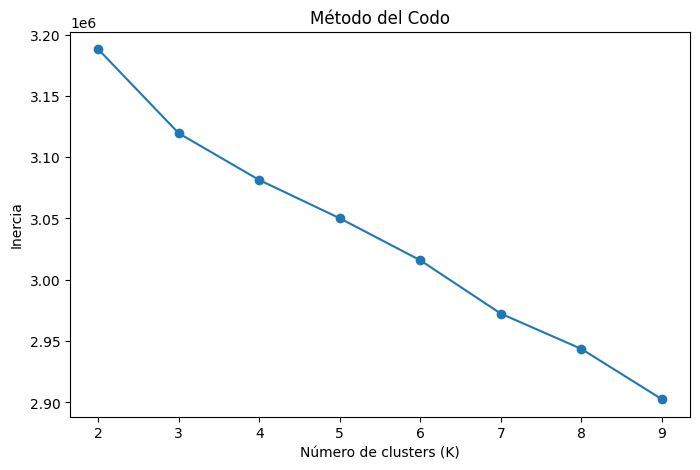

In [ ]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

#Gráfico del codo
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [ ]:
#Ajustar modelo con K óptimo (ejemplo: 3)
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_scaled)

#Obtener etiquetas
labels_kmeans = kmeans.labels_

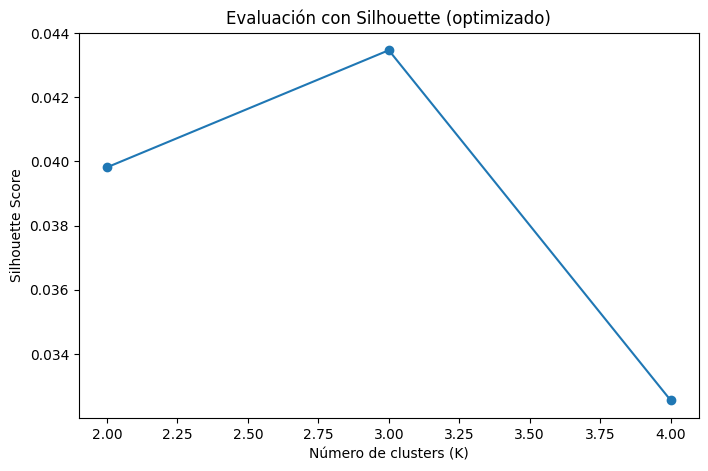

In [ ]:
silhouette_scores = []

#Rango reducido (menos carga computacional)
K_range = range(2, 5)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# 📈 Gráfica
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Evaluación con Silhouette (optimizado)")
plt.show()

## Model Training

In this stage, clustering models were trained with the objective of identifying patterns and natural groupings within the dataset.

Initially, the **K-Means** algorithm was applied, which required determining the optimal number of clusters. To achieve this, two complementary techniques were used: the **Elbow Method**, which evaluates model inertia, and the **Silhouette Score**, which measures the quality of cluster separation.

Based on these methods, the value of **K** that provided the best balance between cluster cohesion and separation was selected.

Subsequently, the K-Means model was trained using the optimal number of clusters, generating labels that assign each observation to a specific group.

Additionally, the **DBSCAN** algorithm was implemented as a density-based clustering alternative. This approach can identify arbitrarily shaped clusters and detect outliers (noise), which are represented by the label **-1**.

Training both models makes it possible to compare their performance and assess which approach better captures the underlying structure of the dataset according to its distribution and characteristics.``

#Evaluación del modelo

In [ ]:

score_kmeans = silhouette_score(X_scaled, labels_kmeans)
print("Silhouette Score - KMeans:", score_kmeans)


Silhouette Score - KMeans: 0.04346335861066312


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
# Verificar que haya más de un cluster válido
if len(set(labels_dbscan)) > 1 and -1 in labels_dbscan:
    score_dbscan = silhouette_score(X_scaled, labels_dbscan)
    print("Silhouette Score - DBSCAN:", score_dbscan)
else:
    print("DBSCAN no generó suficientes clusters para calcular Silhouette")


Silhouette Score - DBSCAN: 0.06861506045797067


In [ ]:
#Distribución de clusters K-Means
print("Clusters K-Means:")
print(pd.Series(labels_kmeans).value_counts())

#Distribución DBSCAN
print("\nClusters DBSCAN:")
print(pd.Series(labels_dbscan).value_counts())

Clusters K-Means:
2    15254
0     9630
1     7677
Name: count, dtype: int64

Clusters DBSCAN:
-1      12626
 13       760
 5        397
 20       347
 109      322
        ...  
 786        5
 823        5
 805        5
 850        5
 765        1
Name: count, Length: 853, dtype: int64


## Model Evaluation

To evaluate the performance of the clustering models, the **Silhouette Score** was used, a metric that measures clustering quality in terms of cohesion within clusters and separation between clusters.

The **K-Means** model achieved a higher Silhouette Score, indicating that observations within each cluster are more similar to one another and better separated from observations in other clusters.

On the other hand, the **DBSCAN** model showed limitations in generating clearly defined clusters, labeling a significant proportion of observations as noise (outliers). While this behavior can be useful in certain scenarios, it reduces its overall segmentation capability for this dataset.

Additionally, the distribution of the clusters generated by each model was analyzed. The results showed that **K-Means** produces more balanced groups, whereas **DBSCAN** tends to create smaller clusters and identify a larger number of outliers.

Overall, these findings suggest that the **K-Means algorithm** is better suited to the structure of this dataset, as it generates more consistent and well-defined clusters.
``